# Companion Notebook for the paper "A COLLATZ RATIONAL LATTICE AND OPERATOR THEORY EVIDENCE FOR COMPLETENESS"

Values are usually presented as a numerator denominator pair.


In [132]:
import sys, io
import math
import numpy as np
import pandas as pd
from scipy.optimize import nnls
from fractions import Fraction
from sympy import factorint
from itertools import product
from typing import List, Optional, Tuple
import random
from scipy.sparse import coo_array
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt


# §2 An algebraic representation

We embrace the 1,4,2,1 cycle of the Collatz Conjecture which in the shortcut form is the 1,2,1 cycle.  This gives a degenerate lattice with useful properties.

A Collatz Path can be expressed algebraically. Starting with the matrix and vector:

$$
A=\begin{pmatrix}-1&2&0\\0&-3&2\\1&0&-1\end{pmatrix}\\
\text{ , } \\
Y=\begin{pmatrix}0&1&0\end{pmatrix}
$$

which gives the solution:

$$
X=\begin{pmatrix}2&1&2\end{pmatrix}
$$


We can construct matrices that for \(Ax = Y\) give an \(x\) that is a Collatz Path by following simple rules that reflect the defined Collatz operations:

$$
\begin{cases}
	\dfrac{n}{2}: & \text{Extend A with }[-1, 2, ...] \text{ and  } Y_0 = 0\\
	\\
	\dfrac{3n+1}{2}: & \text{Extend A with }[-3, 2, ...] \text{ and  } Y_0 = 1\\
\end{cases}
$$

The equation that gives the Collatz Path for \(4\) is then:

$$
\begin{pmatrix}-1&2&0&0\\0&-1&2&0\\0&0&-3&2\\0&1&0&-1\end{pmatrix}x = \begin{pmatrix}0\\0\\1\\0\end{pmatrix}
$$

Giving an $\mathbf{x}$ vector:

$$
\begin{pmatrix}4\\2\\1\\2\end{pmatrix}
$$

If we change the first permuation to the $\dfrac{3n+1}{2}$ case we get the path in the lattice for the rational $\frac{1}{3}$:

$$
\begin{pmatrix}-3&2&0&0\\0&-1&2&0\\0&0&-3&2\\0&1&0&-1\end{pmatrix}x = \begin{pmatrix}0\\0\\1\\0\end{pmatrix}
$$

Giving an $\mathbf{x}$ vector:

$$
\begin{pmatrix}{\frac{1}{3}}\\2\\1\\2\end{pmatrix}
$$

When we develop the $F_0, F_1$ operators we find that the operator logic can be originated at the value $1$ even though the algebraic form with the cycle cannot express a solution with a vector smaller than length 3.


In [7]:
def collatzPath(collatzNumber):
    path = []
    while collatzNumber != 1:
        if (collatzNumber & 1) == 0:
            collatzNumber = collatzNumber // 2
            path.append("1")
        else:
            collatzNumber = (3 * collatzNumber + 1) // 2
            path.append("0")
    return "".join(path)
#
def Ay_L(L):
    """ Generate A matrix and y vector from label string
    """
    rank = len(L) + 2    
    A = np.zeros((rank,rank))
    y = np.zeros((rank))
    for row in range(rank-3):
        if L[row] == "1":
            a_val = -1.0
            y_val = 0.0
        else:
            a_val = -3.0
            y_val = 1.0
        A[row][row] = a_val
        A[row][row+1] = 2.0
        y[row] = y_val
    #
    # Last 3 rows are always the same
    row = rank - 3
    A[row][row] = -1
    A[row][row+1] = 2
    y[row] = 0
    row = rank - 2
    A[row][row] = -3
    A[row][row+1] = 2
    y[row] = 1
    row = rank - 1
    A[row][row] = -1
    A[row][row-2] = 1
    y[row] = 0
    
    return A, y
#
def solve_Ay_L(L):
    """ Solve for the x vector given the label-string
    """
    A, y = Ay_L(L)
    return A, np.linalg.solve(A, y), y
#

In [102]:
solve_Ay_L('1')

(array([[-1.,  2.,  0.],
        [ 0., -3.,  2.],
        [ 1.,  0., -1.]]),
 array([2., 1., 2.]),
 array([0., 1., 0.]))

In [8]:
collatzPath(4)

'11'

In [9]:
solve_Ay_L('11')

(array([[-1.,  2.,  0.,  0.],
        [ 0., -1.,  2.,  0.],
        [ 0.,  0., -3.,  2.],
        [ 0.,  1.,  0., -1.]]),
 array([4., 2., 1., 2.]),
 array([0., 0., 1., 0.]))

In [10]:
solve_Ay_L(collatzPath(27))

(array([[-3.,  2.,  0., ...,  0.,  0.,  0.],
        [ 0., -3.,  2., ...,  0.,  0.,  0.],
        [ 0.,  0., -1., ...,  0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0., ..., -1.,  2.,  0.],
        [ 0.,  0.,  0., ...,  0., -3.,  2.],
        [ 0.,  0.,  0., ...,  1.,  0., -1.]]),
 array([2.700e+01, 4.100e+01, 6.200e+01, 3.100e+01, 4.700e+01, 7.100e+01,
        1.070e+02, 1.610e+02, 2.420e+02, 1.210e+02, 1.820e+02, 9.100e+01,
        1.370e+02, 2.060e+02, 1.030e+02, 1.550e+02, 2.330e+02, 3.500e+02,
        1.750e+02, 2.630e+02, 3.950e+02, 5.930e+02, 8.900e+02, 4.450e+02,
        6.680e+02, 3.340e+02, 1.670e+02, 2.510e+02, 3.770e+02, 5.660e+02,
        2.830e+02, 4.250e+02, 6.380e+02, 3.190e+02, 4.790e+02, 7.190e+02,
        1.079e+03, 1.619e+03, 2.429e+03, 3.644e+03, 1.822e+03, 9.110e+02,
        1.367e+03, 2.051e+03, 3.077e+03, 4.616e+03, 2.308e+03, 1.154e+03,
        5.770e+02, 8.660e+02, 4.330e+02, 6.500e+02, 3.250e+02, 4.880e+02,
        2.440e+02, 1.220e+02, 6.100e+01, 9.200e+0

# §3,4 A lattice of rationals

## Mixed Radix Tuple Form

- N_i is root node and has value 1.  The structure of this node's tuple fell out of the matrix algebra but this node is actually "before" the matrix formulation of the problem.
- F_0, F_1 are the forward propagating operators that can be applied to each node to expand the binary lattice
- G_0, G_1 are the "prepend to label" functions

In [13]:
N_i = ((0,0), [])

def countZeros(label):
    zero_count = 0
    for bit in label:
        if bit == "0":
            zero_count += 1
    return zero_count
#

def Z(L):
    """ Indexes of zeros in label string
    """
    for i in range(len(L)):
        if L[i] == "0":
            yield i
#

def mr_TupItemValue(a_b, a_0):
    """ Value of (a, b) tuple with a_0 added to b so we are not dealing with float limitations
    """
    a,b = a_b
    return (2**a)*(3**(a_0 + b))
#
def mrTupValue(mr_tup):
    """ Compute the value of the given mrTup

        Returns value as a cannonical (numerator, denominator) pair
    """
    # Multiplying the numerator by 3 ** the generation keeps us in integer land
    a_0 = mr_tup[0][0]
    total = mr_TupItemValue(mr_tup[0], a_0)
    for a_b in mr_tup[1]:
        total -= mr_TupItemValue(a_b, a_0)
    frac = Fraction(total, 3**a_0)
    return (frac.numerator, frac.denominator)
#
def F_0(mr_tup):
    return ( (mr_tup[0][0]+1, mr_tup[0][1]-1), mr_tup[1] + [(mr_tup[0][0], mr_tup[0][1]-1)] )
#
def F_1(mr_tup):
    return ((mr_tup[0][0]+1, mr_tup[0][1]), mr_tup[1])
#
def F_rev(mr_tup):
    """ Reverse of either F0 or F1, uses contents of L list to determine COA
    """
    u_tup, v_list = mr_tup
    a,b = u_tup
    a_ = a-1
    b_ = b
    if len(v_list) > 0:
        if v_list[-1][0] == a_:
            b_ = b+1
            if len(v_list) > 1:
                v_list =  [(vt[0], vt[1]) for vt in v_list[0:-1]]
            else:
                v_list = []
    return ((a_, b_), v_list)
#
def G_0(mr_tup):
    return ( (mr_tup[0][0]+1, mr_tup[0][1]-1), [(0,-1)] + [(c+1, d-1) for (c, d) in mr_tup[1]] )
#
def G_1(mr_tup):
    return ((mr_tup[0][0]+1, mr_tup[0][1]), [(c+1, d) for (c, d) in mr_tup[1]])
#
def G_rev(mr_tup):
    """ Reverse of either G_0 or G_1, uses contents of L list to determine COA
    """
    u_tup, v_list = mr_tup
    a,b = u_tup
    a_ = a-1
    b_ = b
    if len(v_list) > 0:
        if v_list[0][0] == 0 and v_list[0][1] == -1:
            # Then we are undoing a G_0 ...
            b_ = b+1
            if len(v_list) == 1:
                v_list = []
            else:
                v_list = [(c-1, d+1) for (c, d) in mr_tup[1][1:]]
        else:
            v_list = [(c-1, d) for (c, d) in mr_tup[1]]
    return ((a_, b_), v_list)
#
def mrTupFromPath(label):
    """ Create an mrTup given a path (label)
    """
    mr_tup = N_i
    for bit in label:
        if bit == "1":
            mr_tup = F_1(mr_tup)
        else:
            mr_tup = F_0(mr_tup)
    return mr_tup
#
def mrTupFromValue(n):
    label = collatzPath(n)
    return mrTupFromPath(label)
#
def mrTupToLaTex(T):
    a, b = T[0]
    s = "\\frac{2^{%d}}{3^{%d}}"%(a, -b)
    L = T[1]
    if len(L) > 0:
        s = s + " - ( "
        plus = "  "
        for c_d in L:
            c, d = c_d
            t = "\\frac{2^{%d}}{3^{%d}}"%(c, -d)
            s = s + plus + t
            plus = " + "
        s = s + " )"
    return "$ " + s + " $"
#

In [146]:
mrTupValue(N_i)

(1, 1)

In [148]:
mrTupValue(F_0(N_i)), mrTupValue(F_1(N_i))

((1, 3), (2, 1))

##  Affine matrix form

This orthogonal form of the Collatz Algebra computes all lattice values of a given generation at once.  The $F_0, F_1$ operators build the lattice left to right, this form builds the lattice top-to-bottom.

We have the bordered diagonal matrices of rank $2^a$ like:
$$
\mathcal{A}_a {\mathbf{X}}_a = {\mathbf{Y}}_a \text{ : }
\begin{pmatrix} 1&0& \dots &0\\1&-{\alpha}_{1} & \dots &0\\ \dots & \dots & \dots & \dots\\1&0& \dots & -{\alpha}_{a-1}\end{pmatrix}{\mathbf{X}}_a = 
\begin{pmatrix} 2^a\\{\beta}_{1}\\ \dots \\{\beta}_{a-1}\end{pmatrix}
$$
Where:
- the first column is all 1's
- the diagonals below row 0 are the negatives of the $\alpha$ values of the affine transform
- $x_0 = 2^a$
- the rest of the $x$ vector values are the $\beta$ values of the affine transforms which can be computed from the label of each node.

Thus we can trivially compute the values of all nodes (the $x_i$) in a generation directly using this form.

In [19]:
def generationAffineParamsFromLabelDirect(label):
    """
    This uses the label to directly drive the computation of the 
        $\alpha x + \beta$ 
    affine transform the label to 
        $2^{len(label)}$
    """
    zeros = [idx for idx, bit in enumerate(label) if bit == '0']
    b = len(zeros)
    alpha = 3**b
    beta = 0
    for i in range(len(zeros)):
        c = zeros[i]
        d = b - i - 1
        beta += ((2**c)*(3**d))
    return (alpha, beta)
#
def generationIntegersDirect(a):
    """
    Generate all integers in the given generation $a$ using only the label of 
    each lattice node to drive the math.

    Due to the sparcity of the integers in the graph, it is faster to
    forward generate, than do it this way.  But this shows
    the math works.
    """
    edge_val = 2**a
    for i in range(edge_val):
        if i == 0:
            yield edge_val
        else:
            idx = 2**a - (i+1)
            label = f"{idx:0{a}b}"
            alpha, beta = generationAffineParamsFromLabelDirect(label)
            delta = edge_val - beta
            if delta % alpha == 0:
                yield delta // alpha
#
def makeGenerationAlgebra_Ay(a):
    """
    Create the per-generation affine matrix (as a sparse matrix) and y vector for a given generation $a$
    """
    A_vals = []
    A_row = []
    A_col = []
    y = np.zeros((2**a))
    # Left most column is always 1
    for i in range(2**a):
        A_vals.append(1)
        A_row.append(i)
        A_col.append(0)
        if i == 0:
            y[0] = 2**a
        else:
            # Create the label based on the node's position
            idx = 2**a - (i+1)
            label = f"{idx:0{a}b}"
            # Get the affine parameters
            alpha, beta = generationAffineParamsFromLabelDirect(label)
            y[i] = beta
            A_vals.append(-alpha)
            A_row.append(i)
            A_col.append(i)
    return (coo_array((np.array(A_vals), (np.array(A_row), np.array(A_col))), shape=(2**a, 2**a))).tocsr(), y
#

In [17]:
for a in range(4, 12, 1):
    A, Y = makeGenerationAlgebra_Ay(a)
    X = spsolve(A, (3**a)*Y)
    for x in X:
        f = Fraction(int(x), 3**a)
        d = f.denominator
        if d == 1:
            n = f.numerator
            print(a, n)

4 16
4 4
4 5
4 1
5 32
5 8
5 10
5 2
5 3
6 64
6 16
6 20
6 4
6 6
6 21
6 5
6 1
7 128
7 32
7 40
7 8
7 12
7 42
7 10
7 2
7 13
7 3
8 256
8 64
8 80
8 16
8 24
8 84
8 20
8 4
8 26
8 6
8 85
8 21
8 5
8 1
9 512
9 128
9 160
9 32
9 48
9 168
9 40
9 8
9 52
9 12
9 170
9 42
9 10
9 2
9 53
9 13
9 17
9 3
10 1024
10 256
10 320
10 64
10 96
10 336
10 80
10 16
10 104
10 24
10 340
10 84
10 20
10 4
10 106
10 26
10 34
10 6
10 341
10 85
10 21
10 5
10 113
10 1
10 35
10 11
11 2048
11 512
11 640
11 128
11 192
11 672
11 160
11 32
11 208
11 48
11 680
11 168
11 40
11 8
11 212
11 52
11 68
11 12
11 682
11 170
11 42
11 10
11 226
11 2
11 70
11 22
11 213
11 53
11 69
11 13
11 17
11 227
11 3
11 75
11 23
11 7


# The beginnings of the lattice

The first few generations of the lattice to make it clear how the represenations come together.

The trivial transformations are:

- tuple $\leftrightarrow$ label
- tuple $\leftrightarrow$ equation
- label $\leftrightarrow$ equation
- tuple or label or equation $\rightarrow$ value or ($\alpha, \beta$)


## Generation 0

| value $X_0,i$ | label | tuple | $\alpha$ | $\beta$| equation |
| ---: | --- | --- | ---: | ---: | --- |
| 1  | "" | ((0,0), []) | 1 | 0 | $\frac{2^0}{3^0}$ |

$ \lvert 1 \rvert {\mathbf{X}}_0 = \lvert 2^0 \rvert $

## Generation 1

| value $X_1,i$ | label | tuple | $\alpha$ | $\beta$ | equation |
| ---: | --- | --- | ---: | ---: | --- |
| $2$  | "1" | $((1,0), [])$ | 1 | 0 | $\frac{2^1}{3^0}$ |
| $\frac{1}{3}$ | "0" | $((1, -1), [(0, -1)])$ | 3 | 1 | $\frac{2^1}{3^{-1}} - (\frac{2^0}{3^{-1}})$ |

$\begin{pmatrix} 
    1&0 \\
    1&-3\\
\end{pmatrix} {\mathbf{X}}_1 = 
\begin{pmatrix} 
    2^1\\ 1\\
\end{pmatrix}$

## Generation 2

| value $X_2,i$ | label | tuple | $\alpha$ | $\beta$ | equation |
| ---: | --- | --- | ---: | ---: | --- |
| $4$  | "11" | $((2,0), [])$ | 1 | 0 | $\frac{2^2}{3^0}$ |
| $\frac{2}{3}$ | "10" | $((2, -1), [(1, -1)])$ | 3 | 2 | $ \frac{2^{2}}{3^{1}} - ( \frac{2^{1}}{3^{1}} ) $ |
| $1$ | "01" | $((2, -1), [(0, -1)])$ | 3 | 1 | $ \frac{2^{2}}{3^{1}} - ( \frac{2^{0}}{3^{1}} ) $ |
| $\frac{-1}{9}$ | "00" | $((2, -2), [(0, -1), (1, -2)])$ | 9 | 5 | $ \frac{2^{2}}{3^{2}} - ( \frac{2^{0}}{3^{1}} + \frac{2^{1}}{3^{2}} ) $ |

$\begin{pmatrix} 
    1&0&0&0 \\
    1&-3&0&0\\
    1&0&-3&0\\
    1&0&0&-9\\
\end{pmatrix} {\mathbf{X}}_2 = 
\begin{pmatrix} 
    2^2\\ 2\\ 1\\ 5\\
\end{pmatrix}$


## Generation 3

| value $X_3,i$ | label | tuple | $\alpha$ | $\beta$ | equation |
| ---: | --- | --- | ---: | ---: | --- |
| $8$  | "111" | $((3,0), [])$ | 1 | 0 | $\frac{2^3}{3^0}$ |
| $\frac{4}{3}$ | "110" | $((3, -1), [(2, -1)])$ | 3 | 4 | $ \frac{2^{3}}{3^{1}} - ( \frac{2^{2}}{3^{1}} )$ |
| $2$ | "101" | $((3, -1), [(1, -1)]$ | 3 | 2 | $ \frac{2^{3}}{3^{1}} - (   \frac{2^{1}}{3^{1}} )  $ |
| $\frac{-2}{9}$ | "100" | $((3, -2), [(1, -1), (2, -2)])$ | 9 | 10 | $ \frac{2^{3}}{3^{2}} - ( \frac{2^{1}}{3^{1}} + \frac{2^{2}}{3^{2}} ) $ |
| $\frac{7}{3}$  | "011" | $((3, -1), [(0, -1)])$ | 3 | 1 | $\frac{2^{3}}{3^{1}} - ( \frac{2^{0}}{3^{1}} )$ |
| $\frac{1}{9}$ | "010" | $((3, -2), [(0, -1), (2, -2)])$ | 9 | 7 | $ \frac{2^{3}}{3^{2}} - ( \frac{2^{0}}{3^{1}} + \frac{2^{2}}{3^{2}} ) $ |
| $\frac{1}{3}$ | "001" | $((3, -2), [(0, -1), (1, -2)])$ | 9 | 5 | $ \frac{2^{3}}{3^{2}} - ( \frac{2^{0}}{3^{1}} + \frac{2^{1}}{3^{2}} ) $ |
| $\frac{-11}{27}$ | "000" | $((3, -3), [(0, -1), (1, -2), (2, -3)])$ | 27 | 19 | $ \frac{2^{3}}{3^{3}} - ( \frac{2^{0}}{3^{1}} + \frac{2^{1}}{3^{2}} + \frac{2^{2}}{3^{3}} )  $ |

$\begin{pmatrix} 
    1&0&0&0&0&0&0&0 \\
    1&-3&0&0&0&0&0&0 \\
    1&0&-3&0&0&0&0&0 \\
    1&0&0&-9&0&0&0&0 \\
    1&0&0&0&-3&0&0&0 \\
    1&0&0&0&0&-9&0&0 \\
    1&0&0&0&0&0&-9&0 \\
    1&0&0&0&0&0&0&-27 \\
\end{pmatrix} {\mathbf{X}}_3 = 
\begin{pmatrix} 
    2^3\\ 4\\ 2\\ 10\\ 1\\ 7\\ 5\\ 19\\
\end{pmatrix}$


In [52]:
label = "00"
T = mrTupFromPath(label)
T, mrTupValue(T), mrTupToLaTex(T)

(((2, -2), [(0, -1), (1, -2)]),
 (-1, 9),
 '$ \\frac{2^{2}}{3^{2}} - (   \\frac{2^{0}}{3^{1}} + \\frac{2^{1}}{3^{2}} ) $')

In [50]:
A, Y = makeGenerationAlgebra_Ay(3)
X = spsolve(A, Y)
X

array([ 8.        ,  1.33333333,  2.        , -0.22222222,  2.33333333,
        0.11111111,  0.33333333, -0.40740741])

In [85]:
print(A)
print(X)

<Compressed Sparse Row sparse array of dtype 'int64'
	with 15 stored elements and shape (8, 8)>
  Coords	Values
  (0, 0)	1
  (1, 0)	1
  (1, 1)	-3
  (2, 0)	1
  (2, 2)	-3
  (3, 0)	1
  (3, 3)	-9
  (4, 0)	1
  (4, 4)	-3
  (5, 0)	1
  (5, 5)	-9
  (6, 0)	1
  (6, 6)	-9
  (7, 0)	1
  (7, 7)	-27
[ 8.          1.33333333  2.         -0.22222222  2.33333333  0.11111111
  0.33333333 -0.40740741]


In [64]:
def S(label):
    T = mrTupFromPath(label)
    accum = 0
    b = T[0][1]
    for c_d in T[1]:
        c, d = c_d
        accum += (2**c * 3**(d - b))
    return accum
#

## The $s_{b+1} = 3 s_{b} + 2^{i_b} $ recursive closure

We can see this in the $\beta$ values above:

- 0,1 from 0
  - 1 = 3*0 + 1 
- 0,2,1,5 from 0,1
  - 2 = 3*0 + 2
  - 1 = 3*0 + 1
  - 5 = 3*1 + 2
- 0,4,2,10,1,7,5,19 from 0,2,1,5
  - 4 = 3*1 + 1
  - 2 = 3*0 + 2
  - 10 = 3*2 + 4
  - 1 = 3*0 + 1
  - 7 = 3*2 + 1
  - 5 = 3*1 + 2
  - 19 = 3*5 + 4


## The Border: powers of 2

In [69]:
mrTupValue(mrTupFromPath("")), mrTupValue(mrTupFromPath("1")), mrTupValue(mrTupFromPath("11")), mrTupValue(mrTupFromPath("111"))

((1, 1), (2, 1), (4, 1), (8, 1))

## Degeneracy -- All values from generation $a-2$ are in generation $a$

$\frac{1}{4}$ of all values in generation $a$, those that have a label that ends in "01" are the values from generation $a-2$

Same value ($5$), different labels ("0111" vs "011101"), tuples ($((4, -1), [(0, -1)])$ vs $((6, -2), [(0, -1), (4, -2)])$), equations:

In [145]:
label = "0111"
T = mrTupFromPath(label)
T, mrTupValue(T), mrTupToLaTex(T)

(((4, -1), [(0, -1)]),
 (5, 1),
 '$ \\frac{2^{4}}{3^{1}} - (   \\frac{2^{0}}{3^{1}} ) $')

In [46]:
label = label + "01"
T = mrTupFromPath(label)
T, mrTupValue(T), mrTupToLaTex(T)

(((6, -2), [(0, -1), (4, -2)]),
 (5, 1),
 '$ \\frac{2^{6}}{3^{2}} - (   \\frac{2^{0}}{3^{1}} + \\frac{2^{4}}{3^{2}} ) $')

## $3n+1$ does not change the distance from 1

$3n+1$ moves "up" in the lattice by replacing the leading "0" of the label of an odd number with a "1"

In [70]:
label = "00111"
T = mrTupFromPath(label)
mrTupValue(T)

(3, 1)

In [71]:
label = "10111"
T = mrTupFromPath(label)
mrTupValue(T)

(10, 1)

## $\frac{n}{2}$ decreases the distance to 1

$\frac{n}{2}$ removes one leading "1" from the label of an even number, shortening the label

In [72]:
label = "0111"
T = mrTupFromPath(label)
mrTupValue(T)

(5, 1)

## Underlying numbers of the lattice get big fast

In [77]:
label = collatzPath(27)
T = mrTupFromPath(label)
a, b = T[0]
s = S(label)
label, (a, b), 2**a, 3**(-b), s, (2**a - s)//3**(-b)

('0010000010100100010000101100010010000001100001110101011101100011110111',
 (70, -41),
 1180591620717411303424,
 36472996377170786403,
 195820718533800070543,
 27)

# §5 Restatement of the Collatz Conjecture in terms of the affine matrix solutions

$$
\lim_{a \to \infty} \mathbb{C}_a = \mathbb{Z}^+
$$

In [97]:
def Pz(a, X):
    """
    Filter integers from vector of rationals
    """
    x_integer = []
    XX = (3**a)*X
    for x in XX:
        f = Fraction(int(x), 3**a)
        if f.denominator == 1:
            x_integer.append(f.numerator)
    return x_integer
#

In [101]:
def Cz(a):
    """
    Collect all Collatz integers present by generation $a$
    """
    A_, Y_ = makeGenerationAlgebra_Ay(a-1)
    X_ = spsolve(A_, Y_)
    x_integer_ = Pz(a, X_)    
    A_a, Y_a = makeGenerationAlgebra_Ay(a)
    X_a = spsolve(A_a, Y_a)
    x_integer_a = Pz(a, X_a)
    return x_integer_ + x_integer_a
#

In [99]:
Cz(4)

[8, 2, 16, 4, 5, 1]

In [100]:
Cz(6)

[32, 8, 10, 2, 3, 64, 16, 20, 4, 6, 21, 5, 1]

# §6 Integer Density in the Lattice

Below we see $\lvert \mathbb{C}_{a} \rvert \approx \frac{5}{3}(\frac{4}{3})^{a+1}$ 

- The integers grow exponentially
- The size of the lattice grows exponentially faster $2^a$
- The integers become more sparse as $a \rightarrow \infty$

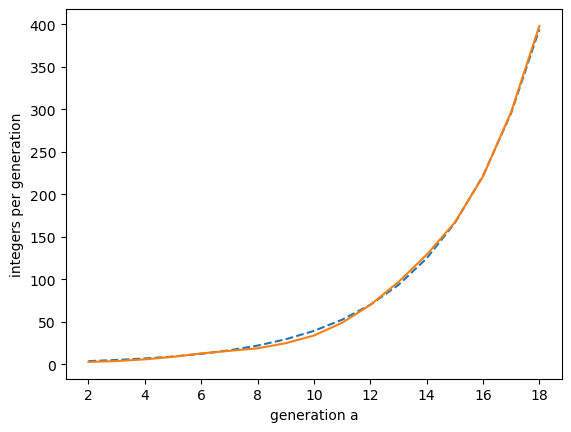

In [133]:
def plotIntegersPerGeneration(a_max):
    X = []
    Y = []
    Y_fit = []
    for a in range(2, a_max+1):
        n = len(Cz(a))
        X.append(a)
        Y.append(n)
        Y_fit.append(5*((4/3)**(a+1))/3)
    plt.plot(X, Y_fit, linestyle='dashed')
    plt.plot(X, Y)
    plt.xlabel("generation a")
    plt.ylabel("integers per generation")
    plt.show()
#
plotIntegersPerGeneration(18)

## Differential Integer Growth Rates in the lattice

Below we can see how the integers of each generation are distributed across the $\pmod{4}$ partitions of the lattice with the "11..." labels producing integers the fastest and the "00..." labels producing integers the slowest.

These differences allow for there to always be an integer in the "11..." part of the lattice that an integer in the lower part of the lattice can have an affine mapping to.  This is in addition to our ability to always generate an affine mapping to $2^a$ for every integer in generation $a$.  Every integer $n$ in the lattice that is not a power of 2 has $\lvert {\sigma}_n \lvert $ integers it can be mapped to via affine transforms "up"; a mapping to $2^a$; its next Collatz number; $2n$ and possibly $F_0(n)$.

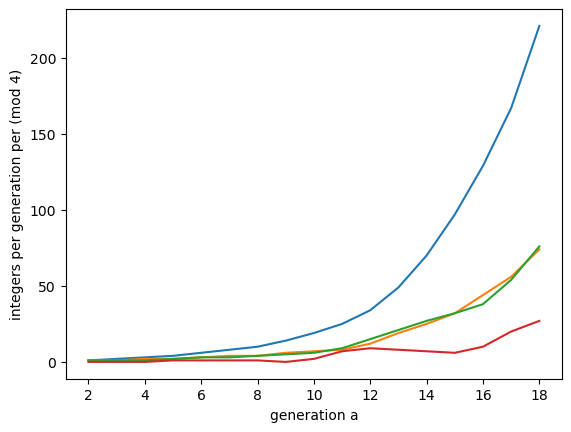

In [136]:
def plotIntegersPerGenerationPerMod4(a_max):
    X = []
    Y = []
    for i in range(4):
        Y.append([])
    for a in range(2, a_max+1):
        for i in range(4):
            Y[i].append(0)
            
        XX = Cz(a)
        for x in XX:
            r = x % 4
            Y[r][-1] = Y[r][-1] + 1
        X.append(a)
    for i in range(4):
        plt.plot(X, Y[i])
    plt.xlabel("generation a")
    plt.ylabel("integers per generation per (mod 4)")
    plt.show()
#
plotIntegersPerGenerationPerMod4(18)

# §7 Correspondence between label prefixes and modulo classes

As we read $a_p$ label prefix bits left to right, they can be associated with a modulus $2^a$ LSB to MSB.  For instance the first bit of a label indicates odd ("0") or even ("1") so the modulus LSB of the odds must be 1 and the evens 0.

All integers in the lattice to the right a given prefix of length $a_p$ will have the same modulus $\pmod{2^{a_p}}$

| label | $\pmod{2^1}$ |
| --- | ---: |
| "1" | $0$ |
| "0" | $1$ |

| label | $\pmod{2^2}$ |
| --- | ---: |
| "11" | $00$ |
| "10" | $10$ |
| "01" | $01$ |
| "00" | $11$ |

| label | $\pmod{2^3}$ |
| --- | ---: |
| "111" | $000$ |
| "110" | $100$ |
| "101" | $010$ |
| "100" | $110$ |
| "011" | $101$ |
| "010" | $001$ |
| "001" | $011$ |
| "000" | $111$ |

The easiest way to generate these mappings is to simply choose a number of a given modulus and compute its Collatz Chain and the prefix of the label gives the mapping.


In [137]:
def generateModulusMappings(a_p):
    m = 2**a_p
    for i in range(m):
        exemplar = m + i
        label = collatzPath(exemplar)
        yield (label[0:a_p], i)
#

In [138]:
sorted(generateModulusMappings(4), reverse=True)

[('1111', 0),
 ('1110', 8),
 ('1101', 4),
 ('1100', 12),
 ('1011', 10),
 ('1010', 2),
 ('1001', 6),
 ('1000', 14),
 ('0111', 5),
 ('0110', 13),
 ('0101', 1),
 ('0100', 9),
 ('0011', 3),
 ('0010', 11),
 ('0001', 7),
 ('0000', 15)]

# §8 Affine mapping between (mod 8) classes

The $\alpha, \beta$ parameters of the affine functions for a given generation $a$ directly fall out of "solving for $2^a$" for each mixed radix equation in the generation.

For instance in generation 3 the label "101" maps to value 2 and equation $ \frac{2^{3}}{3^{1}} - (   \frac{2^{1}}{3^{1}} )  $ so we have:

$$
2 = \frac{2^{3}}{3^{1}} - (   \frac{2^{1}}{3^{1}} )
$$

Solving for the $2^{a} = 2^{3}$ term:

$$
2^{3} = 3(2) + 3(\frac{2^{1}}{3^{1}}) \mapsto 3n + 2
$$

That this applies to every integer in the lattice with the prefix "101" to map that number to a "111" number and that this will always work is not so immediately obvious.  We use the (mod 8) classes to understand the origins of the affine mappings that exist between modulus classes.

### "110" $\mapsto$ "111" Example

The numbers 12 and 40 are both initial found in generation 7 and after their initial 3 bit difference in their labels, they have the same label bits.

We know that the affine mapping for "110" $\mapsto$ "111" is $3n + 4$ and $3(12) + 4 = 40$, so lets look at the corresponding foundational matrices.

In [149]:
# Note that after a 3-bit prefix, these two numbers have the same path
collatzPath(12), collatzPath(40)

('1100111', '1110111')

In [150]:
solve_Ay_L(collatzPath(12))

(array([[-1.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0., -1.,  2.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0., -3.,  2.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0., -3.,  2.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0., -1.,  2.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0., -1.,  2.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0., -1.,  2.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0., -3.,  2.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  1.,  0., -1.]]),
 array([12.,  6.,  3.,  5.,  8.,  4.,  2.,  1.,  2.]),
 array([0., 0., 1., 1., 0., 0., 0., 1., 0.]))

In [151]:
solve_Ay_L(collatzPath(40))

(array([[-1.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0., -1.,  2.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0., -1.,  2.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0., -3.,  2.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0., -1.,  2.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0., -1.,  2.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0., -1.,  2.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0., -3.,  2.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  1.,  0., -1.]]),
 array([40., 20., 10.,  5.,  8.,  4.,  2.,  1.,  2.]),
 array([0., 0., 0., 1., 0., 0., 0., 1., 0.]))

Comparing these two equations, we can eliminate the commonalities and we wind up with the equations which are entirely determined by the label prefixes according to our matrix building rules:

$$
	\begin{bmatrix}
		\mathbf{-1} & \mathbf{2} & 0  \\
		0 & \mathbf{-1} & \mathbf{2}  \\
		0 & 0 & \mathbf{-3}  \\
	\end{bmatrix}
	\begin{bmatrix}
		x_0 \\ x_1 \\ x_2
	\end{bmatrix} = \begin{bmatrix}
		\mathbf{0} \\ \mathbf{0} \\ z-1 
	\end{bmatrix}
$$

$$
	\begin{bmatrix}
		\mathbf{-1} & \mathbf{2} & 0 \\
		0 & \mathbf{-1} & \mathbf{2} \\
		0 & 0 & \mathbf{-1}  \\
	\end{bmatrix}
	\begin{bmatrix}
		x_0' \\ x_1' \\ x_2' 
	\end{bmatrix} = \begin{bmatrix}
		\mathbf{0} \\ \mathbf{0} \\ z 
	\end{bmatrix}
$$

Which leads to:
$$
	\begin{aligned}
		& x_0 = -\frac{4z + 4}{3} \\
		& x_0' = -4z \\
        & \mapsto \\
        & 3x_0 + 4 = x_0'
	\end{aligned}
$$

And we can see that these affine transforms are baked into the lattice because of the structure of the foundational matrices and these affine functions will always work because they are entirely driven by the prefixes and not the values.


### The (mod 8) version of the Collatz Conjecture:

I allude to this in the paper, here is a concrete example

$$
T(n)=
\begin{cases}
	\dfrac{n}{8}, & n \equiv 0 \pmod{8},\\[8pt]
	\dfrac{3n+4}{8}, & n \equiv 4 \pmod{8},\\[8pt]
	\dfrac{3n+2}{8}, & n \equiv 2 \pmod{8},\\[8pt]
	\dfrac{9n+10}{8}, & n \equiv 6 \pmod{8},\\[8pt]
	\dfrac{3n+1}{8}, & n \equiv 5 \pmod{8},\\[8pt]
	\dfrac{9n+7}{8}, & n \equiv 1 \pmod{8},\\[8pt]
	\dfrac{9n+5}{8}, & n \equiv 3 \pmod{8},\\[8pt]
	\dfrac{27n+19}{8}, & n \equiv 7 \pmod{8}.
\end{cases}
$$

This has all the same convergence issues of the traditional $\pmod{2}$ conjecture, but it shows that we can take as big a bite of the problem as we want.

# §9 Generalized affine mapping between $\pmod{2^a}$ classes

Here I give the Python code that was tranlated to math for the paper

In [153]:
def affineFunctionParamsFromPrefix(prefix):
    """
    Return the affine parameters A, B for n' = A*n + B

    (Logic extracted from earlier mapByPrefix function)
    """
    a = len(prefix)
    b = countZeros(prefix)
    accum = 0
    sgn = -1**(a)
    for i in range(a-1):
        sgn = sgn * -1
        P = [2]*(a) 
        if prefix[i] == "0":
            P[i] = 1
        else:
            continue  # y = 0, so product will be 0
        for j in range(i+1, a, 1):
            if prefix[j] == "0":
                P[j] = -3
            else:
                P[j] = -1
        #print((sgn, P))
        accum += (sgn * np.prod(P))

    if prefix[-1] == "0":
        #print((-sgn, [2]*(a-1)))
        accum -= (sgn * (2**(a-1)))
    #print(b, accum)
    return(3**b, int(accum)) # get rid of np.int before returning
#

def prefixForModClass(power_of_2, n):
    mod = n % 4
    prefix = ["11", "01", "10", "00"][mod]
    if power_of_2 > 2:
        a = 3
        while a <= power_of_2:
            p2 = 2**(a)
            mod = n % p2
            exemplar = p2 + mod
            bits = []
            while exemplar != 1:
                if (exemplar & 1) == 0:
                    bits.append("1")
                    exemplar = exemplar // 2
                else:
                    bits.append("0")
                    exemplar = (3 * exemplar + 1) // 2
            next_bit = bits[a-1]
            prefix = prefix + next_bit
            a = a+1
    return prefix
#


# §10 A shadow lattice and the affine mappings

Suppose $5$ was not in the lattice.  We start with:

$$
    \begin{bmatrix} 1 \end{bmatrix} X =  \begin{bmatrix} 5 \end{bmatrix} 
$$

Then generation 1 is:

$$
    \begin{bmatrix} -1&2\\0&1 \end{bmatrix} X =  \begin{bmatrix} 0 & 5 \end{bmatrix} ;\quad X=\begin{bmatrix} 10 & 5 \end{bmatrix}
$$

$$
    \begin{bmatrix} -3&2\\0&1 \end{bmatrix} X =  \begin{bmatrix} 1 & 5 \end{bmatrix} ;\quad X=\begin{bmatrix} \frac{3}{5} & 5 \end{bmatrix}
$$

Then generation 2 is:

$$
    \begin{bmatrix} -1&2&0\\0&-1&2\\0&0&1 \end{bmatrix} X =  \begin{bmatrix} 0 & 0 & 5 \end{bmatrix} ;\quad X=\begin{bmatrix} 20 & 10 & 5 \end{bmatrix}
$$
$$
    \begin{bmatrix} -1&2&0\\0&-3&2\\0&0&1  \end{bmatrix} X =  \begin{bmatrix} 0 & 1 & 5 \end{bmatrix} ;\quad X=\begin{bmatrix} 6 & 3 & 5 \end{bmatrix}
$$

$$
    \begin{bmatrix} -3&2&0\\0&-1&2\\0&0&1 \end{bmatrix} X =  \begin{bmatrix} 1 & 0 & 5 \end{bmatrix} ;\quad X=\begin{bmatrix} \frac{19}{3} & 10 & 5 \end{bmatrix}
$$
$$
    \begin{bmatrix} -3&2&0\\0&-3&2\\0&0&1  \end{bmatrix} X =  \begin{bmatrix} 1 & 1 & 5 \end{bmatrix} ;\quad X=\begin{bmatrix} \frac{5}{3} & 3 & 5 \end{bmatrix}
$$

In [165]:
[
    np.linalg.solve([[-1, 2, 0],[0, -1, 2], [0, 0, 1]], [0,0,5]),
    np.linalg.solve([[-1, 2, 0],[0, -3, 2], [0, 0, 1]], [0,1,5]),
    np.linalg.solve([[-3, 2, 0],[0, -1, 2], [0, 0, 1]], [1,0,5]),
    np.linalg.solve([[-3, 2, 0],[0, -3, 2], [0, 0, 1]], [1,1,5])
]

[array([20., 10.,  5.]),
 array([6., 3., 5.]),
 array([ 6.33333333, 10.        ,  5.        ]),
 array([1.66666667, 3.        , 5.        ])]

### Same Affine Functions for lattice that starts at 1 and 5:

The affine functions that map the lower rows of generation 2 to $5 \cdot 2^a$ are the same as for the lattice that starts at 1:

In [168]:
3*6 + 2, 3*(19/3) +1, 9*(5/3) + 5

(20, 20.0, 20.0)

Which means the matrices of the affine forms of the lattice are the same and only the first value of the affine Y vector changes.

And we see that simply multiplying the mixed addend term in the Value Function gives us the correct values for the shadow lattice.

So any integer not in the lattice that had the Collatz function recursively applied to it would necessarily be in a lattice like this shadow lattice.

In [175]:
def shadowValue(mr_tup):
    """
    A slightly modified version of mrTupValue that correctly generates the lattice
    values for a shadow lattice that starts at 5 using the same mrTup structure of 
    lattice that starts at 1.

    All we had to do is add LATTICE_ROOT which captures the starting point of the shadow lattice.
    """
    LATTICE_ROOT = 5
    a_0 = mr_tup[0][0]
    total = LATTICE_ROOT*mr_TupItemValue(mr_tup[0], a_0)
    for a_b in mr_tup[1]:
        total -= mr_TupItemValue(a_b, a_0)
    frac = Fraction(total, 3**a_0)
    return (frac.numerator, frac.denominator)
#


In [179]:
[
    shadowValue(mrTupFromPath("11")),
    shadowValue(mrTupFromPath("10")),
    shadowValue(mrTupFromPath("01")),
    shadowValue(mrTupFromPath("00"))
]

[(20, 1), (6, 1), (19, 3), (5, 3)]

# §11 Solutions by Zero Count

This is a pretty big aside to the proof, but I believe the tie from the Collatz Conjecture to Ehrhart Theory is interesting and this is where that tie started

I found that it was possible to compute the solutions per generation ($a$) per zero count ($b$) formulaicly for $b \in [0,1,2]$ and believe it is likely possible to extend this to larger $b$ and find a general pattern.  However I did not accomplish this but did find the Ehrhart connection in the process of trying to identify the general pattern.



array([18.,  9., 16.])